# 1) Imports

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_cleaning import get_initial_data
from training_methods import build_model, least_squares
from split import split_data
import warnings
import data_cleaning
from data_cleaning import get_thresholded_data
from evaluation import metrics_summary
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

In [17]:
import importlib
importlib.reload(data_cleaning)

<module 'data_cleaning' from 'c:\\Users\\aleks\\ML_new\\project-1-ai_force\\data_cleaning.py'>

## 2) Defining constants:

In [13]:
## INPUT ##
## input % of dataset you want to use for testing 
path_to_data = os.path.join("..","dataset")
training_ratio = 0.8
seed = 1

## 3) Loading cleaned data

Defining pathway to the dataset.

Loading cleaned data for feature ...
Data cleaning performed:
- NANs replaced with median
- outliers - above ... and below ... percentile were removed

In [18]:
x_train, x_test, y_train, train_ids, test_ids, column_ids=get_thresholded_data(path_to_data,0.3)

In [40]:
print(column_ids)

[  0.   1.   2.   3.   4.   5.   6.   7.   8.  26.  27.  28.  30.  31.
  32.  33.  34.  36.  37.  38.  39.  40.  42.  43.  44.  45.  46.  47.
  48.  50.  51.  52.  53.  57.  58.  59.  60.  61.  62.  63.  65.  66.
  67.  68.  69.  70.  71.  72.  76.  77.  81.  82.  83.  84.  85.  86.
  87.  94.  99. 100. 103. 104. 216. 217. 219. 220. 221. 222. 223. 227.
 229. 230. 231. 232. 233. 234. 235. 236. 237. 238. 239. 240. 241. 242.
 243. 244. 245. 246. 247. 248. 249. 250. 251. 252. 253. 254. 255. 256.
 257. 258. 259. 260. 261. 262. 263. 264. 265. 266. 267. 268. 269. 270.
 271. 272. 273. 274. 275. 276. 277. 278. 279. 280. 281. 282. 283. 284.
 287. 288. 297. 298. 305. 306. 307. 308. 309. 310. 311. 312. 313. 314.
 315. 316. 317. 320.]


In [72]:
x_train.shape 

(328135, 144)

In [30]:
x_test.shape

(109379, 321)

## 4) Data split

Splitting data into a training and testing sets.

In [19]:
x_train, x_test, y_train, y_test = split_data(x, y, training_ratio, )

Checking correlations between variables

In [22]:
x_train.shape

(328135, 145)

In [23]:
# iterating through all the variables
correlations=np.zeros(x_train.shape[1])
for i in range(0,x_train.shape[1]):
    a=np.corrcoef(x_train[:,i],y_train)[0,1]
    correlations[i]=a


In [24]:
correlations.shape

(145,)

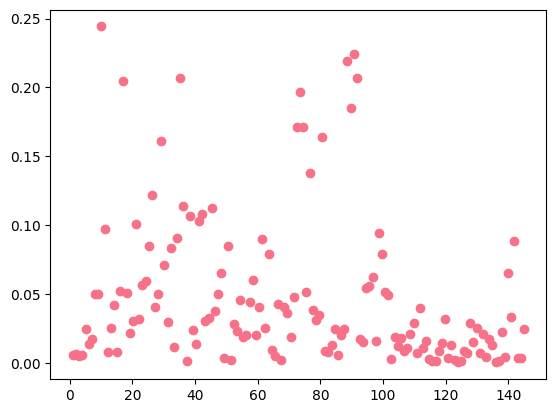

In [25]:
# plotting abs value of the correlations
plt.scatter(np.linspace(0,(correlations.shape[0]),(correlations.shape[0])),np.abs(correlations))

In [35]:
def get_feature_indices_above_threshold(correlations, threshold):

    indeces_relative = np.where(np.abs(correlations) > threshold)[0]
    indeces_absolute = column_ids[indeces_relative]
    return indeces_absolute, indeces_relative
    

In [36]:
useful_features_abs,useful_features_rel=get_feature_indices_above_threshold(correlations, 0.05)

In [39]:
print(useful_features.shape[0])

47


## 4.1) Splitting out my part of data

In [19]:
# data assigned to me is from column index 213 to end
x_train_ola = x_train[:, 213:]
x_test_ola = x_test[:, 213:]
y_train_ola = y_train
y_test_ola = y_test

## 5) Training

In [17]:
# Notation: lectures' notation and derivations from it:
#   w_strain denotes the weights obtained during training
#   f_strain the method for the model parametrized by w_strain
w_strain, loss_strain = least_squares(y_train, x_train)
f_strain = build_model(w_strain)

## 6) Evaluation

In [18]:
y_predicted = f_strain(x_test)
y_predicted = np.sign(y_predicted) #removing sign

accuracy, precision, true_pos_rate, false_pos_rate, f1_score = metrics_summary(y_test, y_predicted)

# Printing results without additional formatting
print("Loss (train):", loss_strain)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("True Positive Rate:", true_pos_rate)
print("False Positive Rate:", false_pos_rate)
print("F1 Score:", f1_score)
print("Weights:", w_strain)

tpr -> TP: 3019, FN: 2644, TPR: 0.5331096591912414
fpr -> FP: 20123, TN: 39841, FPR: 0.33558468414381964
tpr -> TP: 3019, FN: 2644, TPR: 0.5331096591912414
f1 -> Precision: 0.1304554489672457, Recall: 0.5331096591912414, F1: 0.20961638604408958
Loss (train): 0.9969873165488008
Accuracy: 0.6530848583662212
Precision: 0.1304554489672457
True Positive Rate: 0.5331096591912414
False Positive Rate: 0.33558468414381964
F1 Score: 0.20961638604408958
Weights: [-0.05487532]


In [ ]:
# Print the first 5 raw predictions and corresponding true labels from the test set,
# also include predicted label as sign(prediction)
preds = y_predicted[:5]
trues = y_test[:5]
pred_labels = np.sign(preds)

print("Index | Predicted (raw) | Predicted (label) | Actual")
for i, (p, pl, t) in enumerate(zip(preds, pred_labels, trues), start=1):
    print(f"{i:5d} | {p:15.6f} | {int(pl):17d} | {int(t):6d}")

: 

## 7) Visualisation

: 